# 01 Used Car Price Prediction: Initial EDA and Cleaning #

**Project question:** Can we estimate a fair used-car listing price from vehicle characteristics such as make, model, year, mileage, fuel type, transmission, drivetrain, and location?

**Target variable:** `price`

**Notebook output:** `../data/processed.csv`

**Important rule:** I do not overwrite `raw.csv`. The raw dataset stays unchanged so the workflow remains reproducible.

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import seaborn as sns

Loading the CSV, fixing d-type error

In [64]:
df = pd.read_csv('../data/raw.csv', 
        dtype={
            'fuel_type': 'string',
            'engine_block': 'string'
}, 
low_memory=False)

In [65]:
df.dtypes

id                  str
vin                 str
price           float64
miles           float64
stock_no            str
year            float64
make                str
model               str
trim                str
body_type           str
vehicle_type        str
drivetrain          str
transmission        str
fuel_type        string
engine_size     float64
engine_block     string
seller_name         str
street              str
city                str
state               str
zip                 str
dtype: object

Inspection, answering what Columns exists, which are useful/useless, or are there impossible values etc.

In [66]:
df.shape

(393603, 21)

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 393603 entries, 0 to 393602
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            393603 non-null  str    
 1   vin           393603 non-null  str    
 2   price         358486 non-null  float64
 3   miles         366590 non-null  float64
 4   stock_no      365910 non-null  str    
 5   year          393586 non-null  float64
 6   make          393603 non-null  str    
 7   model         388809 non-null  str    
 8   trim          354824 non-null  str    
 9   body_type     359578 non-null  str    
 10  vehicle_type  355365 non-null  str    
 11  drivetrain    354608 non-null  str    
 12  transmission  357922 non-null  str    
 13  fuel_type     322790 non-null  string 
 14  engine_size   320950 non-null  float64
 15  engine_block  320439 non-null  string 
 16  seller_name   391371 non-null  str    
 17  street        385674 non-null  str    
 18  city          3

In [68]:
df.describe()

,price,miles,year,engine_size
count,3.584860e+05,3.665900e+05,393586.000000,320950.000000
mean,2.601902e+04,7.566339e+04,2016.414829,2.785073
std,2.064007e+04,5.775442e+04,3.345400,1.236639
min,0.000000e+00,0.000000e+00,1981.000000,0.600000
25%,1.490000e+04,3.491375e+04,2015.000000,2.000000
50%,2.190000e+04,6.232800e+04,2017.000000,2.400000
75%,3.199500e+04,1.032830e+05,2019.000000,3.500000
max,1.288888e+06,2.300033e+06,2022.000000,8.400000


In [69]:
df.isna().sum().sort_values(ascending=False)

engine_block    73164
engine_size     72653
fuel_type       70813
drivetrain      38995
trim            38779
vehicle_type    38238
transmission    35681
price           35117
body_type       34025
stock_no        27693
miles           27013
street           7929
state            7836
city             7774
zip              7769
model            4794
seller_name      2232
year               17
id                  0
vin                 0
make                0
dtype: int64

In [70]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

### Initial observations

Write this in your own notebook after looking at the outputs above.

Example wording:

- The dataset contains 393603 rows and 21 columns.
- The target column is `price`.
- Several columns have missing values, especially `engine_block`, `engine_size`, and `fuel_type`.
- The missing values are large, for one feature alone approximately 18% are missing values, we must impute values for accuracy
- From .describe() we notice that there are no impossible years, impossible mileage, or impossible engine sizes. 
- The first cleaning priorities are the null values, D-type errors in engine_block and fuel type, and impossible prices.

## Target Variable check: `price`

In [71]:
TARGET = 'price'
df[TARGET].describe()

count    3.584860e+05
mean     2.601902e+04
std      2.064007e+04
min      0.000000e+00
25%      1.490000e+04
50%      2.190000e+04
75%      3.199500e+04
max      1.288888e+06
Name: price, dtype: float64

In [72]:
df[TARGET].isna().sum()

np.int64(35117)

In [73]:
#Checking for negative or zero values in the target variable
df.loc[(df[TARGET] <= 0), [TARGET]].head(20)


,price
3042,0.0
75459,0.0
143974,0.0
143980,0.0
178476,0.0
178477,0.0
288311,0.0
306097,0.0
321642,0.0
330959,0.0


### There are 11 values with a value of 0.0

I will remove rows where `price` is missing or less than or equal to zero because these rows cannot be used to train a supervised price-prediction model. I will not automatically remove expensive vehicles only because they are expensive. High prices may represent real luxury or collectible vehicles, so I will inspect extreme values before deciding whether to cap or remove them.

## Check Categorical Columns
Standardize Text-columns before modelling
Need to check common col values to see that there are no `_  Honda ` or `Honda  ` treated differently from `Honda` else we strip.

In [74]:
text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
text_cols

['id',
 'vin',
 'stock_no',
 'make',
 'model',
 'trim',
 'body_type',
 'vehicle_type',
 'drivetrain',
 'transmission',
 'fuel_type',
 'engine_block',
 'seller_name',
 'street',
 'city',
 'state',
 'zip']

In [75]:
for col in text_cols[:15]:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False).head(15))


--- id ---


id
b39ea795-eca9    1
026cb5b1-6e3e    1
5cd5d5b2-5cc2    1
b32473ed-5922    1
ac40c9fc-0676    1
0487af07-893c    1
b872c7c9-27cd    1
87d61ee5-d1c9    1
e39410c3-ef41    1
19549afd-1a64    1
9bff56cb-9e20    1
e190cc9a-1062    1
031632fa-66c6    1
5c56c5d4-9755    1
9094ac45-009e    1
Name: count, dtype: int64


--- vin ---


vin
2LMDJ8JC2ABJ31372    21
2LMDJ8JC7ABJ14101    21
2LMDJ8JK6EBL14514    21
2LMHJ5AT6EBL57176    21
2LMHJ5AT7BBJ51215    21
2LMPJ8L9XKBL31626    21
2LMPJ8LP6KBL25661    21
2LMPJ8LP7JBL17471    21
2LMTJ8LP8GBL46811    21
3LN6L5F91KR608628    21
3LN6L5F98KR600204    21
3LN6L5FC5HR611035    21
5LMCJ2A97FUJ39247    21
5LMCJ2D93MUL02372    21
5LMCJ2D94JUL12193    21
Name: count, dtype: int64


--- stock_no ---


...

seller_name
autocanada                        8987
calgary motor dealers assn        2520
hgrgoire                          2475
NaN                               2232
performance auto group            2104
steele auto group                 2021
hgrgoire infiniti laval           1970
hgrgoire nissan saint-eustache    1947
hgrgoire nissan vimont            1947
hgrgoire mitsubishi laval         1908
chomedey nissan hgrgoire          1875
hgrgoire nissan blainville        1865
hgrgoire hyundai vaudreuil        1790
open road auto group              1320
candiac toyota                    1247
Name: count, dtype: int64


--- street ---


street
200 15511 123 Ave Nw              8987
NaN                               7929
30 Van Kirk Drive                 3241
11505 35 Street Southeast #107    2520
625 Rue Dubois                    2475
636 Portland St.                  2021
1950 Boulevard Chomedey           1970
272 Rue Dubois                    1947
4540 Boulevard Robert-bourassa    1947
2465 Boulevard Cur-labelle        1908
4299 Autoroute 440                1875
705 Boulevard Cur-labelle         1865
395 Dunlop Street West            1831
101 Rue Joseph-carrier            1790
13251 Smallwood Pl                1320
Name: count, dtype: int64


--- city ---


city
Edmonton          18615
Calgary           15923
Toronto           14998
Laval             11867
Winnipeg           7982
Ottawa             7977
NaN                7774
Mississauga        7456
Brampton           7060
Surrey             6572
Regina             6494
Richmond           6357
London             6280
Vaughan            5293
Saint-eustache     5241
Name: count, dtype: int64

### Categorical cleaning decision

I will standardize text columns by converting values to lowercase and stripping extra spaces. Rare makes or models will be handled during feature engineering. My goal is to retain as much information as possible in the dataset.


# Cleaning the Data 

I want to keep the data cleaning as minimal as possible, I will use these following steps to perform my cleaning: 

1. Keep `raw.csv` unchanged - Work on a copy of the data 
2. Remove duplicates 
3. Remove unusable rows (0.0)
4. Remove impossible numerical values
5. Standardize Text columns 
6. Impute missing values
7. Save the dataset as `processed.csv` 

In [76]:
# 1. Keep raw csv.unchanged
df_cleaned = df.copy()

# 2. Remove duplicates 
df_cleaned = df_cleaned.drop_duplicates()

# 3. Remove rows with 0.0 target values

df_cleaned = df_cleaned[df_cleaned[TARGET]>0]

# 4. Remove rows with impossible values in numerical columns for good practice 

#Mileage, year, and engine size should be within reasonable limits for used cars (Keep NULLS for imputation later)
df_cleaned = df_cleaned[df_cleaned["year"].between(1980, 2026) | df_cleaned["year"].isna()]

df_cleaned = df_cleaned[df_cleaned["miles"].between(0, 500000) | df_cleaned["miles"].isna()]

df_cleaned = df_cleaned[df_cleaned["engine_size"].between(0.6,8.4) | df_cleaned["engine_size"].isna()]

# Create an indicator before replacing 0
df_cleaned["miles_was_zero"] = (df_cleaned["miles"] == 0).astype(int)

# Treat 0 miles as missing
df_cleaned.loc[df_cleaned["miles"] == 0, "miles"] = np.nan

 # 5. Standardize text columns by stripping whitespace and converting to lowercase

for col in text_cols:
    df_cleaned[col] = (
        df_cleaned[col]
        .astype('string')
        .str.lower()
        .str.strip()
        .str.replace(r"[^a-z0-9]", "", regex=True)  # remove punctuation
    )

## Simple imputation

At this stage, I use simple imputation to keep rows with missing predictor values instead of deleting them. Numeric columns are filled with the median because the median is less sensitive to outliers than the mean. Categorical columns are filled with `"unknown"` so missing category information is preserved as its own category.

For the final model evaluation, imputation should be done inside a train/test pipeline to avoid data leakage. This version is mainly for creating a simple cleaned `processed.csv`.

In [77]:
# 6. Impute missing values in numeric columns with median and categorical columns with "unknown"
df_imputed = df_cleaned.copy()

TARGET = "price"

# Separate numeric and categorical predictor columns
numeric_cols = df_imputed.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != TARGET]

categorical_cols = df_imputed.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()


# Numeric imputation: median
numeric_imputer = SimpleImputer(strategy="median")

df_imputed[numeric_cols] = numeric_imputer.fit_transform(
    df_imputed[numeric_cols]
)

# Categorical imputation: unknown
# Convert pandas pd.NA to np.nan first so sklearn does not break
df_imputed[categorical_cols] = (
    df_imputed[categorical_cols]
    .astype("object")
    .replace({pd.NA: np.nan})
)

categorical_imputer = SimpleImputer(
    strategy="constant",
    fill_value="unknown"
)

df_imputed[categorical_cols] = categorical_imputer.fit_transform(
    df_imputed[categorical_cols]
)

# Convert categorical columns back to pandas string type
for col in categorical_cols:
    df_imputed[col] = (
        df_imputed[col]
        .astype("string")
        .str.lower()
        .str.strip()
    )

In [78]:
#7. Save cleaned and imputed dataset for modeling
df_imputed.to_csv("../data/imputed.csv", index=False)

In [ ]:

before_rows = len(df)
after_rows = len(df_imputed)

print(f"Rows before cleaning: {before_rows:,}")
print(f"Rows after cleaning:  {after_rows:,}")
print(f"Rows removed:         {before_rows - after_rows:,}")
print(f"Percent removed:      {(before_rows - after_rows) / before_rows * 100:.2f}%")

Rows before cleaning: 393,603
Rows after cleaning:  358,434
Rows removed:         35,169
Percent removed:      8.94%


### Re-check the cleaned Data
After cleaning I confirm that the cleaning steps did what I expected and did not damage the dataset

In [ ]:
df_imputed.info()

In [ ]:
df_imputed.shape

In [ ]:
df_imputed.isna().sum()


## 9. Basic EDA after cleaning

Now that obvious invalid rows are removed, I can look at the main relationships. This is still exploratory.

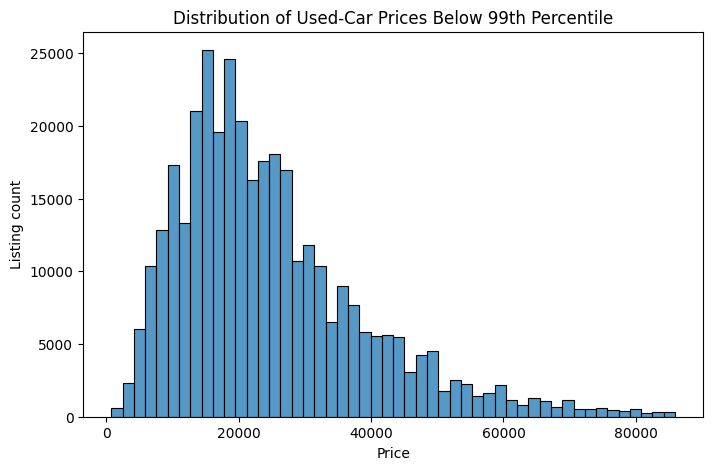

In [95]:
upper_price = df_imputed["price"].quantile(0.99)

plt.figure(figsize=(8, 5))
sns.histplot(
    df_imputed[df_imputed["price"] <= upper_price]["price"],
    bins=50
)
plt.title("Distribution of Used-Car Prices Below 99th Percentile")
plt.xlabel("Price")
plt.ylabel("Listing count")
plt.show()